In [1]:
from google.colab import files
uploaded=files.upload()




import pandas as pd

df = pd.read_csv("market_pipe_thickness_loss_dataset.csv")





Saving market_pipe_thickness_loss_dataset.csv to market_pipe_thickness_loss_dataset.csv


In [2]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("market_pipe_thickness_loss_dataset.csv")

df = pd.read_csv(DATA_PATH)

print("Rows, Columns:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head(5)

Rows, Columns: (1000, 11)

Columns:
 ['Pipe_Size_mm', 'Thickness_mm', 'Material', 'Grade', 'Max_Pressure_psi', 'Temperature_C', 'Corrosion_Impact_Percent', 'Thickness_Loss_mm', 'Material_Loss_Percent', 'Time_Years', 'Condition']


,Pipe_Size_mm,Thickness_mm,Material,Grade,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Condition
0,800,15.48,Carbon Steel,ASTM A333 Grade 6,300,84.9,16.04,4.91,31.72,2,Moderate
1,800,22.00,PVC,ASTM A106 Grade B,150,14.1,7.38,7.32,33.27,4,Critical
2,400,12.05,Carbon Steel,API 5L X52,2500,0.6,2.12,6.32,52.45,7,Critical
3,1500,38.72,Carbon Steel,API 5L X42,1500,52.7,5.58,6.20,16.01,19,Critical
4,1500,24.32,HDPE,API 5L X65,1500,11.7,12.29,8.58,35.28,20,Critical


In [3]:

# Step 2: Professional Data Audit


print("---- DATA TYPES ---")
print(df.dtypes)

print("\n---- TARGET DISTRIBUTION ----")
print(df["Condition"].value_counts())
print("\nTarget %:")
print(df["Condition"].value_counts(normalize=True) * 100)

print("\n---- MISSING VALUES ----")
print(df.isna().sum())

print("\n---- NUMERICAL SUMMARY ----")
display(df.describe())

print("\n---- CATEGORICAL SUMMARY ----")
for col in ["Material", "Grade", "Condition"]:
    print(f"\n{col} unique values:")
    print(df[col].unique())


---- DATA TYPES ---
Pipe_Size_mm                  int64
Thickness_mm                float64
Material                     object
Grade                        object
Max_Pressure_psi              int64
Temperature_C               float64
Corrosion_Impact_Percent    float64
Thickness_Loss_mm           float64
Material_Loss_Percent       float64
Time_Years                    int64
Condition                    object
dtype: object

---- TARGET DISTRIBUTION ----
Condition
Critical    487
Moderate    299
Normal      214
Name: count, dtype: int64

Target %:
Condition
Critical    48.7
Moderate    29.9
Normal      21.4
Name: proportion, dtype: float64

---- MISSING VALUES ----
Pipe_Size_mm                0
Thickness_mm                0
Material                    0
Grade                       0
Max_Pressure_psi            0
Temperature_C               0
Corrosion_Impact_Percent    0
Thickness_Loss_mm           0
Material_Loss_Percent       0
Time_Years                  0
Condition               

,Pipe_Size_mm,Thickness_mm,Max_Pressure_psi,Temperature_C,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,522.000000,16.073530,1004.100000,42.595600,9.745990,4.886300,46.747560,12.961000
std,443.703587,10.548358,812.843099,41.127071,5.817492,2.901123,46.602553,7.135993
min,50.000000,3.000000,150.000000,-50.000000,0.000000,0.010000,0.080000,1.000000
25%,150.000000,7.357500,300.000000,13.400000,4.492500,2.365000,15.665000,7.000000
50%,300.000000,12.930000,900.000000,41.200000,9.720000,4.915000,31.660000,13.000000
75%,800.000000,23.027500,1500.000000,69.150000,14.832500,7.432500,61.035000,19.000000
max,1500.000000,49.530000,2500.000000,149.700000,20.000000,9.990000,318.750000,25.000000



---- CATEGORICAL SUMMARY ----

Material unique values:
['Carbon Steel' 'PVC' 'HDPE' 'Fiberglass' 'Stainless Steel']

Grade unique values:
['ASTM A333 Grade 6' 'ASTM A106 Grade B' 'API 5L X52' 'API 5L X42'
 'API 5L X65']

Condition unique values:
['Moderate' 'Critical' 'Normal']


In [4]:

# Step 3: Controlled Cleaning & Validation


# 1. Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# 2. Remove physically impossible material loss (>100%)
df = df[df["Material_Loss_Percent"] <= 100].reset_index(drop=True)

# 3. Strip whitespace in categorical columns (safe practice)
for col in ["Material", "Grade", "Condition"]:
    df[col] = df[col].astype(str).str.strip()

print("Shape after cleaning:", df.shape)

print("\nNew Target Distribution:")
print(df["Condition"].value_counts())


Shape after cleaning: (881, 11)

New Target Distribution:
Condition
Critical    375
Moderate    292
Normal      214
Name: count, dtype: int64


In [5]:

# Step 4: Feature & Target Definition


from sklearn.model_selection import train_test_split

TARGET = "Condition"

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify feature types
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Categorical features: ['Material', 'Grade']
Numeric features: ['Pipe_Size_mm', 'Thickness_mm', 'Max_Pressure_psi', 'Temperature_C', 'Corrosion_Impact_Percent', 'Thickness_Loss_mm', 'Material_Loss_Percent', 'Time_Years']

Train size: 704
Test size: 177


In [6]:


# Step 4: Updated Preprocessing Pipeline


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Updated preprocessing ready.")



Updated preprocessing ready.


In [7]:

# Step 5: Baseline Model (Scaled Logistic) Without Leakage


from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

baseline_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

baseline_clf.fit(X_train, y_train)
y_pred = baseline_clf.predict(X_test)

print("Baseline (No Leakage) Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nBaseline (No Leakage) Classification Report:\n", classification_report(y_test, y_pred, digits=4))



Baseline (No Leakage) Confusion Matrix:
 [[73  2  0]
 [ 2 51  6]
 [ 0  2 41]]

Baseline (No Leakage) Classification Report:
               precision    recall  f1-score   support

    Critical     0.9733    0.9733    0.9733        75
    Moderate     0.9273    0.8644    0.8947        59
      Normal     0.8723    0.9535    0.9111        43

    accuracy                         0.9322       177
   macro avg     0.9243    0.9304    0.9264       177
weighted avg     0.9334    0.9322    0.9320       177



In [8]:

# Step 5: Random Forest (No Leakage)


from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_split=8,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)

print("Random Forest (No Leakage) Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nRandom Forest (No Leakage) Classification Report:\n", classification_report(y_test, rf_pred, digits=4))



Random Forest (No Leakage) Confusion Matrix:
 [[75  0  0]
 [ 0 59  0]
 [ 0  0 43]]

Random Forest (No Leakage) Classification Report:
               precision    recall  f1-score   support

    Critical     1.0000    1.0000    1.0000        75
    Moderate     1.0000    1.0000    1.0000        59
      Normal     1.0000    1.0000    1.0000        43

    accuracy                         1.0000       177
   macro avg     1.0000    1.0000    1.0000       177
weighted avg     1.0000    1.0000    1.0000       177



In [9]:

# Step 6: Feature Engineering (Professional Level)


import numpy as np

df["Corrosion_Rate"] = df["Corrosion_Impact_Percent"] / (df["Time_Years"] + 1e-6)
df["Pressure_Stress_Index"] = df["Max_Pressure_psi"] / df["Pipe_Size_mm"]
df["Thermal_Stress_Index"] = df["Temperature_C"] / df["Thickness_mm"]
df["Degradation_Exposure"] = df["Corrosion_Impact_Percent"] * df["Time_Years"]

# Rebuild X and y (still excluding leakage features)
leakage_features = ["Thickness_Loss_mm", "Material_Loss_Percent"]

X = df.drop(columns=["Condition"] + leakage_features)
y = df["Condition"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

# Re-split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("New features added.")
print("Total numeric features:", len(numeric_features))




New features added.
Total numeric features: 10


In [10]:

#step 7: Rebuild Preprocessing (After Feature Engineering

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor rebuilt with engineered features.")



Preprocessor rebuilt with engineered features.


In [11]:

# Step 8: Random Forest With Engineered Features

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

rf_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=1000,
        max_depth=None,
        min_samples_split=6,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)

print("Random Forest (Engineered Features) Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nRandom Forest (Engineered Features) Classification Report:\n", classification_report(y_test, rf_pred, digits=4))



Random Forest (Engineered Features) Confusion Matrix:
 [[52 17  6]
 [35 14 10]
 [25 12  6]]

Random Forest (Engineered Features) Classification Report:
               precision    recall  f1-score   support

    Critical     0.4643    0.6933    0.5561        75
    Moderate     0.3256    0.2373    0.2745        59
      Normal     0.2727    0.1395    0.1846        43

    accuracy                         0.4068       177
   macro avg     0.3542    0.3567    0.3384       177
weighted avg     0.3715    0.4068    0.3720       177



In [12]:

# Step 9: Create Binary Target (Critical vs Non-Critical)


# Create binary label
df["Critical_Risk"] = (df["Condition"] == "Critical").astype(int)

# Rebuild X and y (still excluding leakage features)
leakage_features = ["Thickness_Loss_mm", "Material_Loss_Percent"]

X = df.drop(columns=["Condition", "Critical_Risk"] + leakage_features)
y = df["Critical_Risk"]

# Re-identify feature types
categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Binary target distribution:")
print(y.value_counts())



Binary target distribution:
Critical_Risk
0    506
1    375
Name: count, dtype: int64


In [13]:

# Step 10: Preprocessing for Binary Model


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Binary preprocessing ready.")


Binary preprocessing ready.


In [14]:

# Step 11: Binary Random Forest + Risk Metrics


from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

rf_binary = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=1000,
        max_depth=None,
        min_samples_split=6,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_binary.fit(X_train, y_train)

# Predictions
y_pred = rf_binary.predict(X_test)
y_proba = rf_binary.predict_proba(X_test)[:, 1]  # probability of Critical

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

print("\nROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_proba), 4))


Confusion Matrix:
 [[50 52]
 [35 40]]

Classification Report:
               precision    recall  f1-score   support

           0     0.5882    0.4902    0.5348       102
           1     0.4348    0.5333    0.4790        75

    accuracy                         0.5085       177
   macro avg     0.5115    0.5118    0.5069       177
weighted avg     0.5232    0.5085    0.5112       177


ROC-AUC: 0.5668
PR-AUC: 0.4672


In [15]:

# Step 12: Threshold Adjustment


import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

threshold = 0.35
y_pred_adjusted = (y_proba >= threshold).astype(int)

print("Threshold:", threshold)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_adjusted))
print("\nClassification Report:\n", classification_report(y_test, y_pred_adjusted, digits=4))


Threshold: 0.35

Confusion Matrix:
 [[30 72]
 [10 65]]

Classification Report:
               precision    recall  f1-score   support

           0     0.7500    0.2941    0.4225       102
           1     0.4745    0.8667    0.6132        75

    accuracy                         0.5367       177
   macro avg     0.6122    0.5804    0.5179       177
weighted avg     0.6332    0.5367    0.5033       177



In [16]:

# Step 13: Risk Scoring & Operational Bands


risk_df = X_test.copy()
risk_df["Actual_Critical"] = y_test.values
risk_df["Risk_Probability"] = y_proba

# Define risk bands
def risk_band(p):
    if p >= 0.60:
        return "High Risk"
    elif p >= 0.35:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["Risk_Band"] = risk_df["Risk_Probability"].apply(risk_band)

print(risk_df[["Risk_Probability", "Risk_Band", "Actual_Critical"]].head(10))

print("\nRisk Band Distribution:")
print(risk_df["Risk_Band"].value_counts())


     Risk_Probability    Risk_Band  Actual_Critical
382          0.612840    High Risk                1
860          0.444745  Medium Risk                0
215          0.342131     Low Risk                1
135          0.502592  Medium Risk                1
29           0.464190  Medium Risk                1
85           0.509764  Medium Risk                1
558          0.595116  Medium Risk                0
731          0.478473  Medium Risk                1
246          0.600861    High Risk                1
779          0.485878  Medium Risk                1

Risk Band Distribution:
Risk_Band
Medium Risk    101
Low Risk        40
High Risk       36
Name: count, dtype: int64


In [17]:

# Step 14

band_analysis = risk_df.groupby("Risk_Band")["Actual_Critical"].agg(
    total="count",
    critical_cases="sum"
)

band_analysis["critical_rate"] = band_analysis["critical_cases"] / band_analysis["total"]

print(band_analysis)


             total  critical_cases  critical_rate
Risk_Band                                        
High Risk       36              17       0.472222
Low Risk        40              10       0.250000
Medium Risk    101              48       0.475248


In [18]:

# Step 15: XGBoost (Binary Critical Risk)


!pip -q install xgboost

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

xgb_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_clf.fit(X_train, y_train)

xgb_pred = xgb_clf.predict(X_test)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]

print("XGBoost Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))
print("\nXGBoost Classification Report:\n", classification_report(y_test, xgb_pred, digits=4))
print("\nROC-AUC:", round(roc_auc_score(y_test, xgb_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, xgb_proba), 4))


XGBoost Confusion Matrix:
 [[67 35]
 [44 31]]

XGBoost Classification Report:
               precision    recall  f1-score   support

           0     0.6036    0.6569    0.6291       102
           1     0.4697    0.4133    0.4397        75

    accuracy                         0.5537       177
   macro avg     0.5367    0.5351    0.5344       177
weighted avg     0.5469    0.5537    0.5489       177


ROC-AUC: 0.5761
PR-AUC: 0.4672


In [19]:

# Step 16: Time-Series Simulation + Failure Label (Fail within 12 months)


import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# --- Configuration ---
MONTHS = 60                 # simulate 5 years monthly
HORIZON = 12                # predict failure within next 12 months
LOSS_THRESHOLD_MM = 5.0     # failure threshold (aligned with earlier Critical boundary)

# Create stable Asset IDs
df = df.copy()
df["Asset_ID"] = np.arange(1, len(df) + 1)

# We'll simulate using non-leakage features + engineered drivers already in df if present
base_cols = [
    "Asset_ID",
    "Pipe_Size_mm", "Thickness_mm", "Material", "Grade",
    "Max_Pressure_psi", "Temperature_C", "Corrosion_Impact_Percent", "Time_Years"
]
base_cols = [c for c in base_cols if c in df.columns]

assets = df[base_cols].copy()

rows = []
for _, a in assets.iterrows():
    asset_id = int(a["Asset_ID"])

    # Base parameters (fixed per asset)
    pipe_size = float(a["Pipe_Size_mm"])
    thickness0 = float(a["Thickness_mm"])
    max_p = float(a["Max_Pressure_psi"])
    temp0 = float(a["Temperature_C"])
    corr0 = float(a["Corrosion_Impact_Percent"])
    age_years = float(a["Time_Years"])

    # Convert base corrosion impact to a monthly degradation "rate"
    # This is synthetic but physically plausible: higher corrosion + higher pressure + higher temp => faster loss.
    # Scale factors tuned so some assets fail within 5 years.
    base_rate = (0.0025 * corr0) + (0.00015 * (max_p / 1000.0)) + (0.00010 * (max(temp0, 0) / 50.0))
    base_rate *= (1.0 + 0.02 * min(age_years, 25))  # older assets degrade slightly faster

    # Initialize state
    thickness_loss = 0.0
    failed_month = None

    for m in range(1, MONTHS + 1):
        # Simulate operational readings (monthly snapshots)
        # add realistic variability + mild seasonality in temperature
        temp = temp0 + 10.0 * np.sin(2 * np.pi * (m / 12.0)) + rng.normal(0, 3.0)
        pressure = max_p * (0.85 + 0.10 * rng.normal(0, 1.0))
        corrosion = max(0.0, min(20.0, corr0 + rng.normal(0, 1.0)))

        # Degradation increment (mm/month)
        # higher corrosion & pressure & temperature => higher increment; add noise
        inc = base_rate
        inc *= (1.0 + 0.06 * (corrosion - corr0) / (max(corr0, 1e-6)))  # sensitivity to corrosion fluctuations
        inc *= (1.0 + 0.04 * ((pressure / max_p) - 0.85))               # sensitivity to pressure excursions
        inc *= (1.0 + 0.03 * (max(temp, 0) / 50.0))                     # sensitivity to temperature
        inc += rng.normal(0, 0.01)

        inc = max(0.0, inc)  # no negative degradation

        thickness_loss += inc

        # Remaining thickness (not strictly needed but useful later)
        remaining_thickness = max(0.0, thickness0 - thickness_loss)

        # Failure rule: loss crosses threshold OR remaining thickness too low
        if failed_month is None and (thickness_loss >= LOSS_THRESHOLD_MM or remaining_thickness <= 0.25 * thickness0):
            failed_month = m

        rows.append({
            "Asset_ID": asset_id,
            "Month": m,
            "Pipe_Size_mm": pipe_size,
            "Thickness_mm": thickness0,
            "Material": a.get("Material", None),
            "Grade": a.get("Grade", None),
            "Max_Pressure_psi": max_p,
            "Temperature_C": temp,
            "Corrosion_Impact_Percent": corrosion,
            "Pressure_psi": pressure,
            "Thickness_Loss_mm_sim": thickness_loss,
            "Remaining_Thickness_mm": remaining_thickness,
            "Failed_Month": failed_month if failed_month is not None else 0
        })

ts = pd.DataFrame(rows)

# Create "time-to-failure" per row (in months); 0 if never fails in window
# For rows after failure, keep TTF = 0 (already failed)
ts["TTF_months"] = 0
fail_month_by_asset = ts.groupby("Asset_ID")["Failed_Month"].max()
ts = ts.merge(fail_month_by_asset.rename("Failed_Month_Final"), on="Asset_ID", how="left")

mask_has_fail = ts["Failed_Month_Final"] > 0
ts.loc[mask_has_fail, "TTF_months"] = (ts.loc[mask_has_fail, "Failed_Month_Final"] - ts.loc[mask_has_fail, "Month"]).clip(lower=0)

# Binary label: will it fail within next HORIZON months?
ts["Fail_Within_12M"] = ((ts["TTF_months"] > 0) & (ts["TTF_months"] <= HORIZON)).astype(int)

print("Simulated time-series shape:", ts.shape)
print("Assets:", ts["Asset_ID"].nunique(), "| Months per asset (expected):", MONTHS)
print("\nFail_Within_12M distribution:")
print(ts["Fail_Within_12M"].value_counts())


Simulated time-series shape: (52860, 16)
Assets: 881 | Months per asset (expected): 60

Fail_Within_12M distribution:
Fail_Within_12M
0    52740
1      120
Name: count, dtype: int64


In [20]:

# Step 17: Asset-Level Train/Test Split


from sklearn.model_selection import train_test_split

# Get unique asset IDs
asset_ids = ts["Asset_ID"].unique()

train_ids, test_ids = train_test_split(
    asset_ids,
    test_size=0.20,
    random_state=42
)

train_df = ts[ts["Asset_ID"].isin(train_ids)].copy()
test_df  = ts[ts["Asset_ID"].isin(test_ids)].copy()

print("Train rows:", train_df.shape[0])
print("Test rows:", test_df.shape[0])

print("\nTrain Fail_Within_12M distribution:")
print(train_df["Fail_Within_12M"].value_counts())

print("\nTest Fail_Within_12M distribution:")
print(test_df["Fail_Within_12M"].value_counts())


Train rows: 42240
Test rows: 10620

Train Fail_Within_12M distribution:
Fail_Within_12M
0    42168
1       72
Name: count, dtype: int64

Test Fail_Within_12M distribution:
Fail_Within_12M
0    10572
1       48
Name: count, dtype: int64


In [21]:

# Step 18: Rolling Time-Series Feature Engineering


ts = ts.sort_values(["Asset_ID", "Month"]).copy()

# Monthly degradation increment
ts["Loss_Increment"] = ts.groupby("Asset_ID")["Thickness_Loss_mm_sim"].diff().fillna(0)

# Rolling mean (3-month window)
ts["Loss_RollingMean_3"] = (
    ts.groupby("Asset_ID")["Loss_Increment"]
    .rolling(3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# Rolling std
ts["Loss_RollingStd_3"] = (
    ts.groupby("Asset_ID")["Loss_Increment"]
    .rolling(3, min_periods=1)
    .std()
    .reset_index(level=0, drop=True)
    .fillna(0)
)

# Degradation acceleration (second derivative)
ts["Loss_Acceleration"] = (
    ts.groupby("Asset_ID")["Loss_Increment"]
    .diff()
    .fillna(0)
)

print("New time-series features created.")


New time-series features created.


In [22]:

# Step 19: Remove Post-Failure Rows


# Keep rows before or at failure, or assets that never failed
ts_model = ts[
    (ts["Failed_Month_Final"] == 0) |
    (ts["Month"] <= ts["Failed_Month_Final"])
].copy()

print("Shape after removing post-failure rows:", ts_model.shape)

print("\nFail_Within_12M distribution (cleaned):")
print(ts_model["Fail_Within_12M"].value_counts())


Shape after removing post-failure rows: (52760, 20)

Fail_Within_12M distribution (cleaned):
Fail_Within_12M
0    52640
1      120
Name: count, dtype: int64


In [23]:


# Step 20: Split ts_model by Asset_ID (Leakage Safe)


from sklearn.model_selection import train_test_split

asset_ids = ts_model["Asset_ID"].unique()
train_ids, test_ids = train_test_split(asset_ids, test_size=0.20, random_state=42)

train_df = ts_model[ts_model["Asset_ID"].isin(train_ids)].copy()
test_df  = ts_model[ts_model["Asset_ID"].isin(test_ids)].copy()

print("Train rows:", train_df.shape[0], "| positives:", int(train_df["Fail_Within_12M"].sum()))
print("Test rows:", test_df.shape[0], "| positives:", int(test_df["Fail_Within_12M"].sum()))


Train rows: 42214 | positives: 72
Test rows: 10546 | positives: 48


In [24]:

# Step 21: Define Modeling Features


drop_cols = [
    "Asset_ID",
    "Month",
    "Failed_Month",
    "Failed_Month_Final",
    "TTF_months",
    "Fail_Within_12M"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Fail_Within_12M"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["Fail_Within_12M"]

# Identify feature types
categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numeric_features = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical:", categorical_features)
print("Numeric feature count:", len(numeric_features))


Categorical: ['Material', 'Grade']
Numeric feature count: 12


In [25]:

# Step 22: Rare-Event XGBoost Training


from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# Calculate class weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight:", round(scale_pos_weight, 2))

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# XGBoost model
xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_model)
])

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]

print("\nROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC:", round(average_precision_score(y_test, y_proba), 4))


scale_pos_weight: 585.31

ROC-AUC: 0.9994
PR-AUC: 0.8205


In [26]:

# Step 23: Operational Threshold Analysis


import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

threshold = 0.10   # start conservative for rare events

y_pred = (y_proba >= threshold).astype(int)

print("Threshold:", threshold)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

inspection_rate = y_pred.mean()
print("\nInspection rate:", round(inspection_rate * 100, 3), "%")


Threshold: 0.1

Confusion Matrix:
 [[10482    16]
 [    4    44]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9996    0.9985    0.9990     10498
           1     0.7333    0.9167    0.8148        48

    accuracy                         0.9981     10546
   macro avg     0.8665    0.9576    0.9069     10546
weighted avg     0.9984    0.9981    0.9982     10546


Inspection rate: 0.569 %


In [27]:

# Step 24: Extract Feature Importance


import pandas as pd
import numpy as np

# Get feature names after preprocessing
feature_names = (
    model.named_steps["preprocess"]
    .get_feature_names_out()
)

# Get importance values from XGBoost
importances = model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Top 15 Most Important Features:")
display(importance_df.head(15))


Top 15 Most Important Features:


,Feature,Importance
7,num__Remaining_Thickness_mm,0.719875
1,num__Thickness_mm,0.244472
21,cat__Grade_ASTM A333 Grade 6,0.008432
6,num__Thickness_Loss_mm_sim,0.008085
3,num__Temperature_C,0.003875
2,num__Max_Pressure_psi,0.002458
13,cat__Material_Fiberglass,0.002338
14,cat__Material_HDPE,0.002123
17,cat__Grade_API 5L X42,0.001493
9,num__Loss_RollingMean_3,0.001474


In [28]:

# Step 25: Early Warning Mode (remove direct "state" features)


from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report

# Drop direct degradation state features to force earlier detection
early_warning_drop = [
    "Remaining_Thickness_mm",
    "Thickness_Loss_mm_sim",
]

drop_cols = [
    "Asset_ID", "Month",
    "Failed_Month", "Failed_Month_Final",
    "TTF_months", "Fail_Within_12M"
] + early_warning_drop

X_train_ew = train_df.drop(columns=drop_cols, errors="ignore")
y_train_ew = train_df["Fail_Within_12M"]

X_test_ew = test_df.drop(columns=drop_cols, errors="ignore")
y_test_ew = test_df["Fail_Within_12M"]

categorical_features_ew = X_train_ew.select_dtypes(include="object").columns.tolist()
numeric_features_ew = X_train_ew.select_dtypes(exclude="object").columns.tolist()

print("Early-warning numeric features:", len(numeric_features_ew))
print("Early-warning categorical features:", categorical_features_ew)

# class weight
neg = (y_train_ew == 0).sum()
pos = (y_train_ew == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight:", round(scale_pos_weight, 2))

# preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_ew = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_ew),
        ("cat", categorical_transformer, categorical_features_ew)
    ]
)

# model
xgb_model_ew = XGBClassifier(
    n_estimators=900,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

model_ew = Pipeline(steps=[
    ("preprocess", preprocessor_ew),
    ("model", xgb_model_ew)
])

model_ew.fit(X_train_ew, y_train_ew)

y_proba_ew = model_ew.predict_proba(X_test_ew)[:, 1]

print("\nEARLY-WARNING ROC-AUC:", round(roc_auc_score(y_test_ew, y_proba_ew), 4))
print("EARLY-WARNING PR-AUC:", round(average_precision_score(y_test_ew, y_proba_ew), 4))


Early-warning numeric features: 10
Early-warning categorical features: ['Material', 'Grade']
scale_pos_weight: 585.31

EARLY-WARNING ROC-AUC: 0.9503
EARLY-WARNING PR-AUC: 0.1976


In [29]:

# Step 26: Early Warning Threshold + Lead Time


import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

threshold = 0.05   # lower threshold to increase recall for early detection

y_pred_ew = (y_proba_ew >= threshold).astype(int)

print("Threshold:", threshold)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_ew, y_pred_ew))
print("\nClassification Report:\n", classification_report(y_test_ew, y_pred_ew, digits=4))

inspection_rate = y_pred_ew.mean()
print("\nInspection rate:", round(inspection_rate * 100, 3), "%")

# Lead-time analysis
ew_eval = test_df[["Asset_ID", "Month", "TTF_months", "Fail_Within_12M"]].copy()
ew_eval["proba"] = y_proba_ew
ew_eval["pred"] = y_pred_ew

tp = ew_eval[(ew_eval["pred"] == 1) & (ew_eval["Fail_Within_12M"] == 1)].copy()

print("\nTrue Positive count:", len(tp))

if len(tp) > 0:
    print("\nLead time (TTF_months) summary:")
    display(tp["TTF_months"].describe())

    print("\nTop 10 earliest warnings:")
    display(tp.sort_values("TTF_months", ascending=False).head(10)[
        ["Asset_ID", "Month", "TTF_months", "proba"]
    ])


Threshold: 0.05

Confusion Matrix:
 [[10457    41]
 [   37    11]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9965    0.9961    0.9963     10498
           1     0.2115    0.2292    0.2200        48

    accuracy                         0.9926     10546
   macro avg     0.6040    0.6126    0.6081     10546
weighted avg     0.9929    0.9926    0.9928     10546


Inspection rate: 0.493 %

True Positive count: 11

Lead time (TTF_months) summary:


,TTF_months
count,11.000000
mean,7.636364
std,3.413875
min,2.000000
25%,5.500000
50%,8.000000
75%,10.500000
max,12.000000



Top 10 earliest warnings:


,Asset_ID,Month,TTF_months,proba
6642,111,43,12,0.968115
6643,111,44,11,0.273929
48999,817,40,11,0.645417
6644,111,45,10,0.957412
20329,339,50,9,0.257647
49002,817,43,8,0.610638
20331,339,52,7,0.747494
49003,817,44,7,0.070169
6650,111,51,4,0.191732
49007,817,48,3,0.506650


In [30]:
# Recreate risk_snapshot (minimal version)

risk_snapshot = test_df.copy()

risk_snapshot["Imminent_Failure_Prob"] = y_proba
risk_snapshot["Early_Warning_Prob"] = y_proba_ew

# Define tiers again
IMMINENT_THR = 0.10
EARLY_THR = 0.05

def risk_tier(imminent_p, early_p):
    if imminent_p >= IMMINENT_THR:
        return "HIGH RISK (Imminent)"
    elif early_p >= EARLY_THR:
        return "MEDIUM RISK (Early Trend)"
    else:
        return "LOW RISK"

risk_snapshot["Risk_Tier"] = [
    risk_tier(i, e)
    for i, e in zip(risk_snapshot["Imminent_Failure_Prob"],
                    risk_snapshot["Early_Warning_Prob"])
]

# Keep latest month per asset
risk_snapshot = (
    risk_snapshot.sort_values(["Asset_ID", "Month"])
    .groupby("Asset_ID", as_index=False)
    .tail(1)
    .reset_index(drop=True)
)

print("risk_snapshot recreated.")


risk_snapshot recreated.


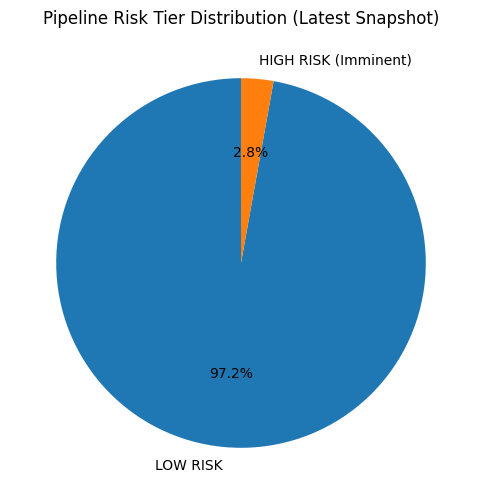

In [31]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
risk_snapshot["Risk_Tier"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Pipeline Risk Tier Distribution (Latest Snapshot)")
plt.ylabel("")
plt.show()




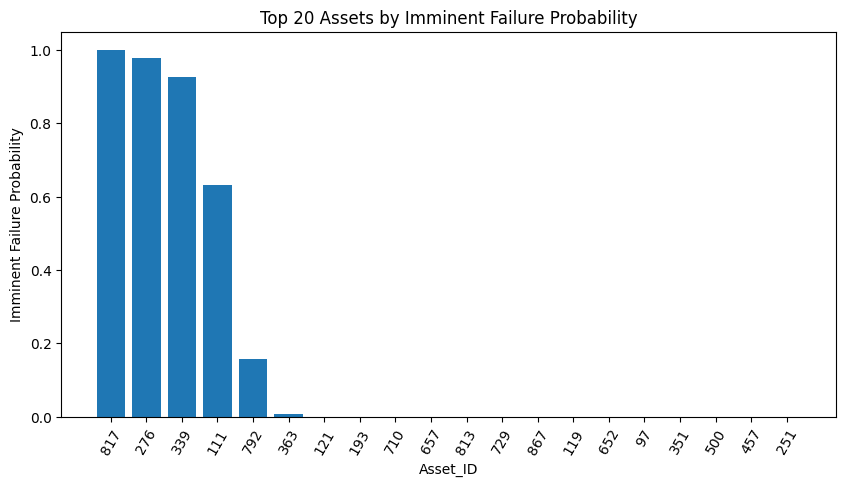

In [32]:
topN = 20
top_risk_assets = risk_snapshot.sort_values("Imminent_Failure_Prob", ascending=False).head(topN)

plt.figure(figsize=(10,5))
plt.bar(top_risk_assets["Asset_ID"].astype(str), top_risk_assets["Imminent_Failure_Prob"])
plt.title(f"Top {topN} Assets by Imminent Failure Probability")
plt.xlabel("Asset_ID")
plt.ylabel("Imminent Failure Probability")
plt.xticks(rotation=60)
plt.show()


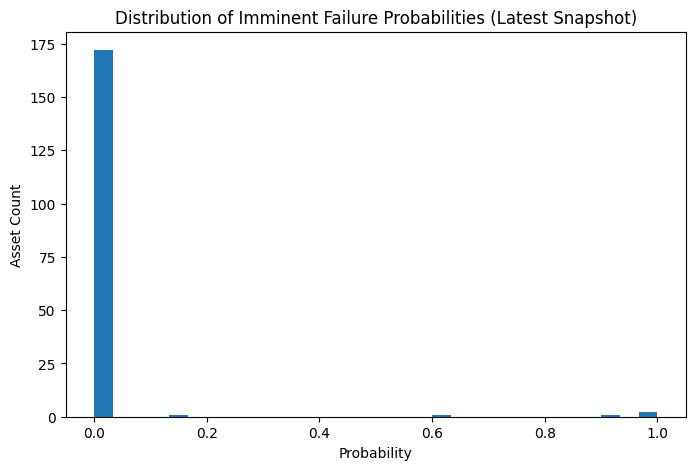

In [33]:
plt.figure(figsize=(8,5))
plt.hist(risk_snapshot["Imminent_Failure_Prob"], bins=30)
plt.title("Distribution of Imminent Failure Probabilities (Latest Snapshot)")
plt.xlabel("Probability")
plt.ylabel("Asset Count")
plt.show()


In [34]:
from pathlib import Path

out_dir = Path("outputs/dashboard_images")
out_dir.mkdir(parents=True, exist_ok=True)

# Save pie chart
plt.figure(figsize=(6,6))
risk_snapshot["Risk_Tier"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Pipeline Risk Tier Distribution (Latest Snapshot)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(out_dir / "risk_tier_distribution.png", dpi=200)
plt.close()

# Save top risk bar
topN = 20
top_risk_assets = risk_snapshot.sort_values("Imminent_Failure_Prob", ascending=False).head(topN)

plt.figure(figsize=(10,5))
plt.bar(top_risk_assets["Asset_ID"].astype(str), top_risk_assets["Imminent_Failure_Prob"])
plt.title(f"Top {topN} Assets by Imminent Failure Probability")
plt.xlabel("Asset_ID")
plt.ylabel("Imminent Failure Probability")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(out_dir / "top_risk_assets.png", dpi=200)
plt.close()

# Save probability histogram
plt.figure(figsize=(8,5))
plt.hist(risk_snapshot["Imminent_Failure_Prob"], bins=30)
plt.title("Distribution of Imminent Failure Probabilities (Latest Snapshot)")
plt.xlabel("Probability")
plt.ylabel("Asset Count")
plt.tight_layout()
plt.savefig(out_dir / "imminent_probability_distribution.png", dpi=200)
plt.close()

# Save dashboard table
Path("outputs").mkdir(exist_ok=True)
risk_snapshot.to_csv("outputs/risk_snapshot.csv", index=False)

print("Saved:")
print("- outputs/risk_snapshot.csv")
print("- outputs/dashboard_images/*.png")


Saved:
- outputs/risk_snapshot.csv
- outputs/dashboard_images/*.png


In [35]:
from pathlib import Path
import matplotlib.pyplot as plt
import shutil

# Folders
out_dir = Path("outputs/dashboard_images")
out_dir.mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(exist_ok=True)

# 1) Save CSV snapshot
risk_snapshot.to_csv("outputs/risk_snapshot.csv", index=False)

# 2) Save visuals (3 PNGs)

# Pie: Risk tier distribution
plt.figure(figsize=(6,6))
risk_snapshot["Risk_Tier"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Pipeline Risk Tier Distribution (Latest Snapshot)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(out_dir / "risk_tier_distribution.png", dpi=200)
plt.close()

# Bar: Top risk assets
topN = 20
top_risk_assets = risk_snapshot.sort_values("Imminent_Failure_Prob", ascending=False).head(topN)

plt.figure(figsize=(10,5))
plt.bar(top_risk_assets["Asset_ID"].astype(str), top_risk_assets["Imminent_Failure_Prob"])
plt.title(f"Top {topN} Assets by Imminent Failure Probability")
plt.xlabel("Asset_ID")
plt.ylabel("Imminent Failure Probability")
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(out_dir / "top_risk_assets.png", dpi=200)
plt.close()

# Histogram: Probability distribution
plt.figure(figsize=(8,5))
plt.hist(risk_snapshot["Imminent_Failure_Prob"], bins=30)
plt.title("Distribution of Imminent Failure Probabilities (Latest Snapshot)")
plt.xlabel("Probability")
plt.ylabel("Asset Count")
plt.tight_layout()
plt.savefig(out_dir / "imminent_probability_distribution.png", dpi=200)
plt.close()

# 3) Zip outputs for download
zip_path = shutil.make_archive("pipeline_dashboard_outputs", "zip", "outputs")
print("Saved outputs and created:", zip_path)


Saved outputs and created: /content/pipeline_dashboard_outputs.zip


In [36]:
from google.colab import files
files.download("pipeline_dashboard_outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>